In [32]:
# Pooling Layers and DImensionality Reduction

In [33]:
# Introduction to Pooling Layers:

# Pooling Layers:
    # -Used to reduce the dimensions of feature maps while retaining the most important information
    # -Help make the network computationally efficient and robust to variations in the input

    # Types of Pooling:
        # 1. Max Pooling:
            # -Selects the maximum value from each region of the input feature map
            # -captures the strong activations(features)
        # 2.Average Pooling:
            # -computes the average value for each region of the input feature map.
            # -provides a more generalized summary of features


# Role of Pooling in Reducing Dimensionality

# Dimensionality Reduction:
    # -Pooling reduces the spatial dimensions (height and width) of feature maps, resulting in fewer parameters and faster computations.

# Robustness:
    # -Makes the model invariant to small translations or distortions in the input image

In [34]:
# Combining Convolution and Pooling Layers

# -Pooling layers typically follow convolutional layers to downsample the feature maps
# -this combination helps extract hierarchical features
    # -Early layers focus on simple features (eg edges)
    # -Deeper layers capture complex patterns (eg objects)

In [35]:
# Exercise: Objective:
    # -Implement max pooling and average pooling layers on the features maps and observe their effects on size and representation

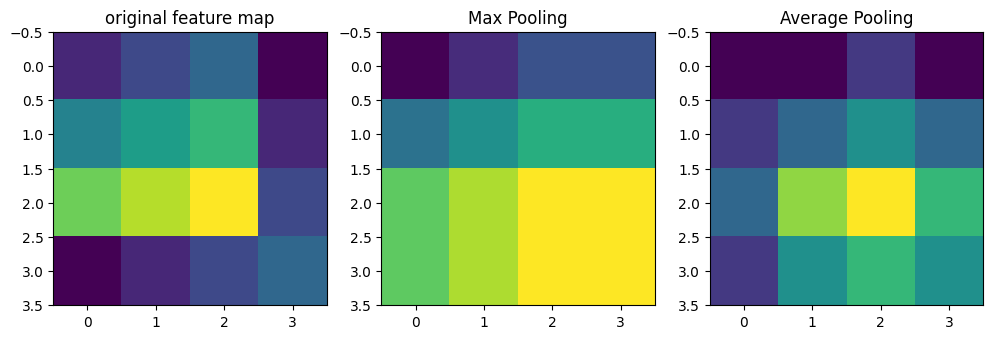

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, uniform_filter

# create a sample feature map
feature_map = np.array([
    [1,2,3,0],
    [4,5,6,1],
    [7,8,9,2],
    [0,1,2,3]
])

# Create max pooling(2x2)
max_pooled = maximum_filter(feature_map, size=2, mode='constant')
# performing max pooling with kernel size of 2x2 and each region in the feature map is replaced with maximum value

# average pooling
avg_pooled = uniform_filter(feature_map, size=2, mode='constant')
# Average pooling with kernel size 2x2, and with each region is replaced with the average of its vcalues

# plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(feature_map, cmap='viridis')
axes[0].set_title("original feature map")
axes[1].imshow(max_pooled, cmap='viridis')
axes[1].set_title("Max Pooling")
axes[2].imshow(avg_pooled, cmap='viridis')
axes[2].set_title("Average Pooling")
plt.show()

max pooled tensor:
 [[5. 6.]
 [8. 9.]]
average pooled tensor:
 [[3.  2.5]
 [4.  4. ]]


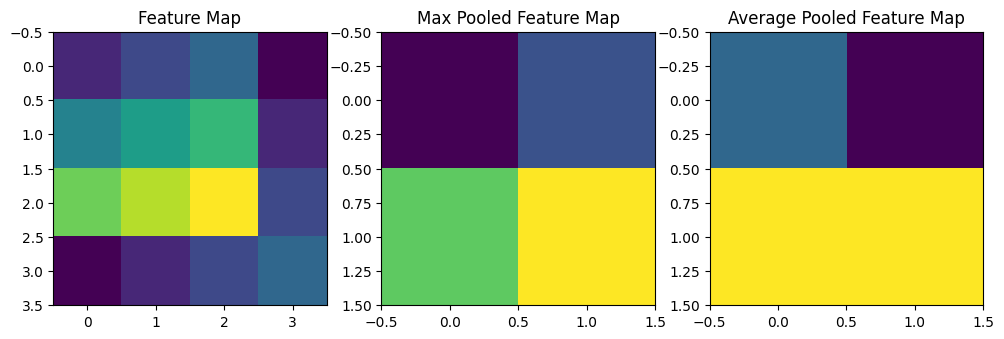

In [43]:
# Pooling layers in tensorflow
import tensorflow as tf

# create a sample input tensor (1x4x4x1 for batch size, height, width, channels)
input_tensor = tf.constant(feature_map.reshape(1, 4, 4, 1), dtype=tf.float32)

# Converting feature map into 4D tensor with batch size, height, widht and channel

# Max pooling
max_pool = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid')
max_pooled_tensor = max_pool(input_tensor)

# Average pooling
avg_pool = tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=2, padding='valid')
avg_pooled_tensor = avg_pool(input_tensor)

print(f"max pooled tensor:\n {tf.squeeze(max_pooled_tensor).numpy()}")
print(f"average pooled tensor:\n {tf.squeeze(avg_pooled_tensor).numpy()}")


# plot the feature map and the max and average pooled feature maps
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(feature_map, cmap='viridis')
plt.title('Feature Map')
plt.subplot(1, 3, 2)
plt.imshow(tf.squeeze(max_pooled_tensor).numpy(), cmap='viridis')
plt.title('Max Pooled Feature Map')
plt.subplot(1, 3, 3)
plt.imshow(tf.squeeze(avg_pooled_tensor).numpy(), cmap='viridis')
plt.title('Average Pooled Feature Map')
plt.show()

In [38]:
# tensor flow example
model_tf = tf.keras.Sequential([
    tf.keras.Input((32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.AveragePooling2D((2,2))

])

model_tf.summary()




Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 6, 6, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

max pooled tensor:
 [[5. 6.]
 [8. 9.]]
average pooled tensor:
 [[3.  2.5]
 [4.  4. ]]


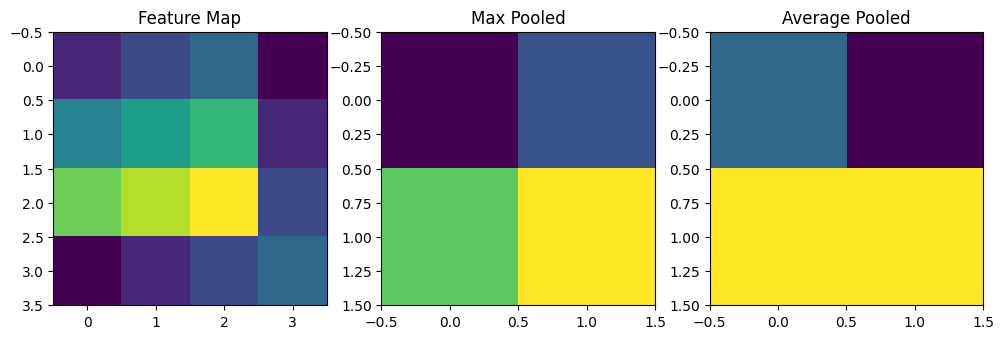

In [44]:

import torch 
import torch.nn as nn

# create a sample input tensor(batch_size, channel, heigh, width)
input_tensor = torch.tensor(feature_map, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# max pooling
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
max_pooled_tensor = max_pool(input_tensor)

# average pooling
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
avg_pooled_tensor = avg_pool(input_tensor)

print(f"max pooled tensor:\n {(max_pooled_tensor.squeeze().numpy())}")
print(f"average pooled tensor:\n {(avg_pooled_tensor.squeeze().numpy())}")

# plot the feature maps, max pooled and average pooled
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(feature_map, cmap='viridis')
plt.title('Feature Map')
plt.subplot(1, 3, 2)
plt.imshow(max_pooled_tensor.squeeze().numpy(), cmap='viridis')
plt.title('Max Pooled')
plt.subplot(1, 3, 3)
plt.imshow(avg_pooled_tensor.squeeze().numpy(), cmap='viridis')
plt.title('Average Pooled')
plt.show()



In [40]:
# PyTorch Example:
class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.pool1 = nn.MaxPool2d((2,2))
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool2 = nn.AvgPool2d((2,2))
        
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        return x

model = SimpleCNN()
print(model)



SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
)


In [41]:
# PyTorch Example:
class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.fc1 = torch.nn.Linear(in_features=64 * 7 * 7, out_features=128)
        self.fc2 = torch.nn.Linear(in_features=128, out_features=10)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()
print(model)


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
